In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
# Your exact working directory for the generated input hex files and source image
BASE_DIR = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python"

# The absolute path to the Verilog simulation output
LOG_FILE_PATH = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/run/imager_reconstruction.txt"

In [3]:
# =======================================================================
# PART 1: GENERATE 1-BIT IMAGER DATA FOR VERILOG
# =======================================================================
def generate_verilog_data():
    print(f"Loading 'papa.png', downsizing to 128x128, and outputting to:\n{BASE_DIR}...")
    
    # 1. Load the user image, convert to Grayscale ('L'), and resize to 128x128
    # Make sure 'papa.png' is in the same directory where you run this script
    img = Image.open('papa.png').convert('L')
    img = img.resize((128, 128))
    
    # Save source for side-by-side comparison later
    source_path = os.path.join(BASE_DIR, "source_image.png")
    img.save(source_path)
    
    # Binarize to 0 (Black) and 1 (White). 
    # Pixels > 128 become white (1), otherwise black (0).
    img_array = np.array(img) > 128 

    # 2. Split into 4 quadrants (64x64 each)
    quads = {
        0: img_array[0:64, 0:64],     # Top-Left
        1: img_array[0:64, 64:128],   # Top-Right
        2: img_array[64:128, 0:64],   # Bottom-Left
        3: img_array[64:128, 64:128]  # Bottom-Right
    }

    # 3. Pack 8 pixels into bytes and write to hex files
    for ch, quad in quads.items():
        # UPDATED: Changed the filename to ch{ch}_papa.txt
        file_path = os.path.join(BASE_DIR, f"ch{ch}_papa.txt")
        with open(file_path, "w") as f:
            for row in range(64):
                for word in range(8): # 8 words * 8 pixels = 64 pixels per row
                    byte_val = 0
                    for bit in range(8):
                        pixel = int(quad[row, (word * 8) + bit])
                        byte_val |= (pixel << (7 - bit)) # Pack MSB first
                    f.write(f"{byte_val:02x}\n")
                    
    print("Successfully generated ch0_papa.txt through ch3_papa.txt!")

In [4]:
# =======================================================================
# PART 2: PARSE VERILOG OUTPUT AND RECONSTRUCT
# =======================================================================
def reconstruct_image():
    # Fetching the explicit absolute path generated by xrun
    log_file = LOG_FILE_PATH
    
    if not os.path.exists(log_file):
        print(f"\nError: {log_file} not found.")
        print("Make sure your xrun simulation has finished and generated the file!")
        return

    print(f"\nParsing {log_file}...")
    with open(log_file, "r") as f:
        lines = f.readlines()[1:] # Skip the CH3 CH2 CH1 CH0 header

    # 128x128 array for the final output
    final_img = np.zeros((128, 128), dtype=np.uint8)
    
    # Offsets to stitch the 4 quadrants back together
    x_offsets = {0: 0, 1: 64, 2: 0, 3: 64}
    y_offsets = {0: 0, 1: 0, 2: 64, 3: 64}

    # Parse each channel independently to handle the hardware's asynchronous drift
    for ch in range(4):
        col_index = 3 - ch # Columns in text file are CH3, CH2, CH1, CH0
        
        in_frame = False
        row_idx = 0
        word_idx = 0
        
        for line in lines:
            parts = line.split()
            if len(parts) != 4: continue
            
            hex_str = parts[col_index].lower()
            
            # Skip Dummy, Padding, and Unknowns generated by the Verilog TB
            if hex_str in ['2aa', '3cc', 'xxx']:
                continue
                
            val = int(hex_str, 16)
            
            # Extract the 10-bit structure
            sof  = (val >> 9) & 1
            sor  = (val >> 8) & 1
            data = val & 0xFF
            
            # Anchor: Start of Frame
            if sof == 1:
                in_frame = True
                row_idx = 0
                word_idx = 0
            
            if not in_frame:
                continue
                
            # Anchor: Start of Row (if not also SOF)
            if sor == 1 and sof == 0:
                row_idx += 1
                word_idx = 0
                
            if row_idx >= 64:
                continue # Ignore wrap-around if the TB runs longer than 1 frame
                
            # Unpack the 8 bits back into 1-bit pixels
            y = y_offsets[ch] + row_idx
            
            for bit in range(8):
                pixel_val = (data >> (7 - bit)) & 1
                x = x_offsets[ch] + (word_idx * 8) + bit
                
                # NEW: Safety boundary check. 
                # Ensures 'x' and 'y' stay strictly within this specific 64x64 quadrant.
                if x < (x_offsets[ch] + 64) and y < (y_offsets[ch] + 64):
                    final_img[y, x] = pixel_val * 255 # Scale to 255 for visibility
                
            word_idx += 1

    # =======================================================================
    # DISPLAY: SIDE-BY-SIDE COMPARISON
    # =======================================================================
    print("Reconstruction complete. Displaying Image...")
    
    source_path = os.path.join(BASE_DIR, "source_image.png")
    
    # Setup matplotlib with 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.canvas.manager.set_window_title('Imager Digital Twin Verification')
    
    # Plot 1: The Original Input
    if os.path.exists(source_path):
        src_img = Image.open(source_path)
        axes[0].imshow(src_img, cmap='gray')
    else:
        axes[0].text(0.5, 0.5, 'Source image not found', ha='center')
        
    axes[0].set_title("Original Input Pattern", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Plot 2: The Reconstructed Output
    axes[1].imshow(final_img, cmap='gray')
    axes[1].set_title("Reconstructed ASIC SPI Output", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [5]:
# Step 1: Generate the input files for Verilog
generate_verilog_data()

Loading 'papa.png', downsizing to 128x128, and outputting to:
/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python...
Successfully generated ch0_papa.txt through ch3_papa.txt!



Parsing /LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/run/imager_reconstruction.txt...
Reconstruction complete. Displaying Image...


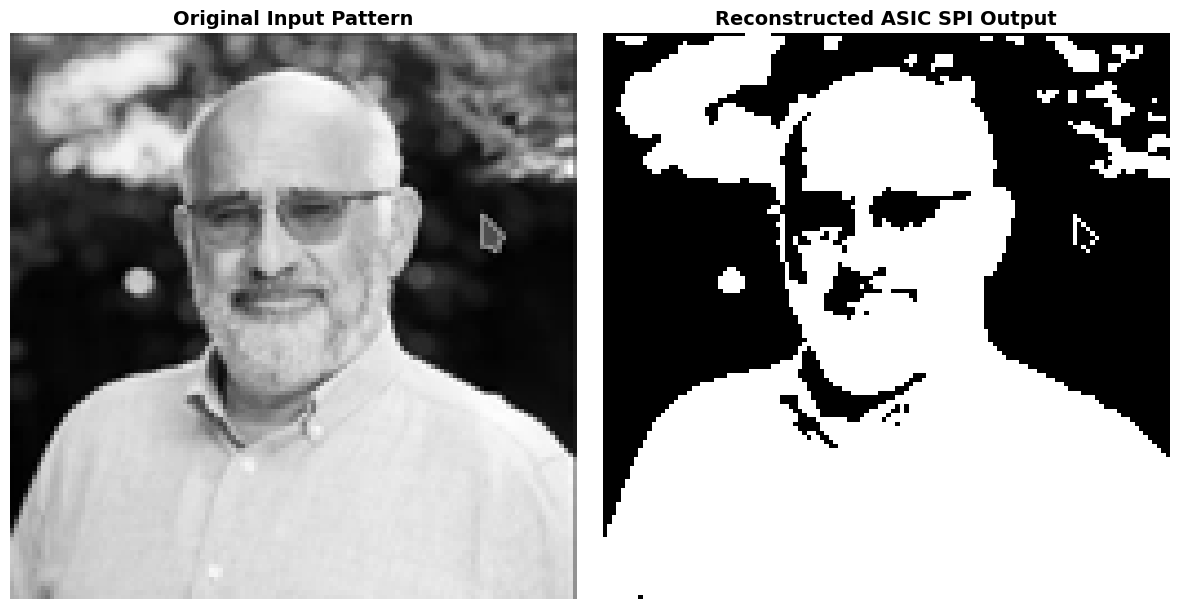

In [17]:
# Step 2: Uncomment the line below AFTER running your Verilog simulation
reconstruct_image()